### Imports and Configuration

In [1]:
from pipeline_utils import make_case1_paths
import pandas as pd
import numpy as np

# Configure paths
paths = make_case1_paths()

PROJECT_DIR = paths["project"]
RAW_DIR = paths["raw_uhn"]
PROC_DIR = paths["proc"]
RESULTS_DIR = paths["results"]

print(f"Project directory: {PROJECT_DIR}")
print(f"Raw data directory: {RAW_DIR}")
print(f"Processed data directory: {PROC_DIR}")
print(f"Results directory: {RESULTS_DIR}")

# Input files
breast_fold_results = PROC_DIR / "growth_ml_fold_results_breast.csv"
breast_pred_results = PROC_DIR / "growth_ml_predictions_breast.csv"
breast_dt_rna_file = PROC_DIR / "rna_doubling_time_merged_breast.csv"

lung_fold_results = PROC_DIR / "growth_ml_fold_results_lung.csv"
lung_pred_results = PROC_DIR / "growth_ml_predictions_lung.csv"
lung_dt_rna_file = PROC_DIR / "rna_doubling_time_merged_lung.csv"

df_results_breast = pd.read_csv(breast_fold_results)
df_preds_breast = pd.read_csv(breast_pred_results)
df_dt_rna_breast = pd.read_csv(breast_dt_rna_file, index_col=0)

df_results_lung = pd.read_csv(lung_fold_results)
df_preds_lung = pd.read_csv(lung_pred_results)
df_dt_rna_lung = pd.read_csv(lung_dt_rna_file, index_col=0)

print(f"breast ML results file: {breast_fold_results}")
print(f"breast ML prediction file: {breast_pred_results}")
print(f"breast ML input file: {breast_dt_rna_file}")
print(f"lung ML results file: {lung_fold_results}")
print(f"lung ML prediction file: {lung_pred_results}")
print(f"lung ML input file: {lung_dt_rna_file}")

# Output files
roc_compare_plot = RESULTS_DIR / "figure2e_Model_Comparison.png"
roc_plot = RESULTS_DIR / "figure2f_ROC.png"
shap_breast_plot = RESULTS_DIR / "Figure2_SHAP_Compact_breast.png"
shap_breast_output = RESULTS_DIR / "SHAP_Global_Gene_Importance_breast.csv"
shap_lung_plot = RESULTS_DIR / "Figure2_SHAP_Compact_lung.png"
shap_lung_output = RESULTS_DIR / "SHAP_Global_Gene_Importance_lung.csv"


/Users/guanqiaofeng/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project directory: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study
Raw data directory: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/0_datasets
Processed data directory: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/1_doublingRate
Results directory: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate


breast ML results file: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/1_doublingRate/growth_ml_fold_results_breast.csv
breast ML prediction file: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/1_doublingRate/growth_ml_predictions_breast.csv
breast ML input file: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/1_doublingRate/rna_doubling_time_merged_breast.csv
lung ML results file: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/1_doublingRate/growth_ml_fold_results_lung.csv
lung ML prediction file: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/1_doublingRate/growth_ml_predictions_lung.csv
lung ML input file: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/1_doublingRate/rna_doubling_time_merged_lung.csv


### Model performance barplot

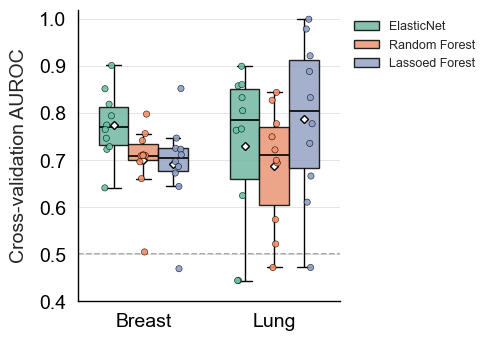

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Summarize fold AUROCs within each CV repeat before plotting
dataset_specs = {
    "Breast": {"results": df_results_breast, "n_splits": 5},
    "Lung": {"results": df_results_lung, "n_splits": 3},
}
model_names = ["ElasticNet", "RandomForest", "LassoedForest"]
model_labels = {
    "ElasticNet": "ElasticNet",
    "RandomForest": "Random Forest",
    "LassoedForest": "Lassoed Forest",
}
model_colors = {
    "ElasticNet": "#66c2a5",
    "RandomForest": "#fc8d62",
    "LassoedForest": "#8da0cb",
}

repeat_results = []
for dataset_name, spec in dataset_specs.items():
    tmp = spec["results"].loc[
        spec["results"]["Model"].isin(model_names),
        ["Model", "Fold", "AUROC"],
    ].dropna().copy()
    tmp["Repeat"] = ((tmp["Fold"].astype(int) - 1) // spec["n_splits"]) + 1
    tmp = tmp.groupby(["Repeat", "Model"], as_index=False)["AUROC"].mean()
    tmp["Dataset"] = dataset_name
    repeat_results.append(tmp)

plot_df = pd.concat(repeat_results, ignore_index=True)
plot_df["Model label"] = plot_df["Model"].map(model_labels)
palette = {model_labels[m]: model_colors[m] for m in model_names}
dataset_order = list(dataset_specs)
hue_order = [model_labels[m] for m in model_names]

# Nature-style box plots with every repeat-level value visible
sns.set_theme(style="whitegrid", context="paper", font="Arial")
fig, ax = plt.subplots(figsize=(5, 3.5))
sns.boxplot(
    data=plot_df, x="Dataset", y="AUROC", hue="Model label",
    order=dataset_order, hue_order=hue_order, palette=palette,
    width=0.68, linewidth=1.0, showfliers=False, showmeans=True,
    meanprops={"marker": "D", "markerfacecolor": "white",
               "markeredgecolor": "black", "markersize": 4},
    boxprops={"edgecolor": "black", "linewidth": 1.0, "alpha": 0.85},
    whiskerprops={"color": "black", "linewidth": 1.0},
    capprops={"color": "black", "linewidth": 1.0},
    medianprops={"color": "black", "linewidth": 1.2}, ax=ax,
)
sns.stripplot(
    data=plot_df, x="Dataset", y="AUROC", hue="Model label",
    order=dataset_order, hue_order=hue_order, palette=palette,
    dodge=True, jitter=0.08, size=4.5, alpha=0.9,
    edgecolor="black", linewidth=0.4, legend=False, ax=ax, zorder=3,
)

ax.axhline(0.5, color="#777777", linestyle="--", linewidth=1.1,
           alpha=0.8, zorder=0)
ax.set_xlabel("")
ax.set_ylabel("Cross-validation AUROC", fontsize=14, labelpad=8)
ax.tick_params(axis="x", labelsize=14, colors="black", width=1.0)
ax.tick_params(axis="y", labelsize=14, colors="black", width=1.0)
ax.set_ylim(0.4, 1.02)
ax.legend(title="", loc="upper left", bbox_to_anchor=(1.01, 1.0),
          fontsize=9, frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("black")
ax.spines["bottom"].set_color("black")
ax.spines["left"].set_linewidth(1.0)
ax.spines["bottom"].set_linewidth(1.0)
ax.grid(axis="y", color="#D9D9D9", linewidth=0.7, alpha=0.7, zorder=0)

plt.tight_layout()
plt.savefig(roc_compare_plot, dpi=300, bbox_inches="tight")
plt.show()

### Model performance summary table

In [3]:
import pandas as pd
import numpy as np
from scipy import stats

# Per-fold performance summary (AUROC, Spearman, Pearson) for each classifier x cohort,
# plus a one-sample t-test of AUROC against chance (0.5). Same test -- and the same
# "repeated-CV folds are not fully independent" caveat -- used for the AUROCs reported
# in the case study 4 (paclitaxel) results; kept consistent across case studies.
dataset_specs = {
    "Breast": df_results_breast,
    "Lung": df_results_lung,
}
model_names = ["ElasticNet", "RandomForest", "LassoedForest"]
model_labels = {
    "ElasticNet": "ElasticNet",
    "RandomForest": "Random Forest",
    "LassoedForest": "Lassoed Forest",
}

summary_rows = []
for cohort, df in dataset_specs.items():
    for model in model_names:
        g = df.loc[df["Model"] == model]
        auroc = g["AUROC"].dropna()
        t_stat, p_value = stats.ttest_1samp(auroc, popmean=0.5)
        summary_rows.append({
            "Cohort": cohort,
            "Model": model_labels[model],
            "n_folds": int(auroc.count()),
            "AUROC_mean": auroc.mean(),
            "AUROC_sd": auroc.std(ddof=0),
            "AUROC_t_stat_vs_chance": t_stat,
            "AUROC_p_value_vs_chance": p_value,
            "Spearman_mean": g["Spearman"].mean(),
            "Spearman_sd": g["Spearman"].std(ddof=0),
            "Pearson_mean": g["Pearson"].mean(),
            "Pearson_sd": g["Pearson"].std(ddof=0),
        })

performance_summary = pd.DataFrame(summary_rows)
performance_summary_file = RESULTS_DIR / "growth_ml_performance_summary.csv"
performance_summary.to_csv(performance_summary_file, index=False)

print(f"Saved model performance summary (mean +/- population SD across completed folds; "
      f"AUROC one-sample t-test vs. chance = 0.5) to {performance_summary_file}")
performance_summary

Saved model performance summary (mean +/- population SD across completed folds; AUROC one-sample t-test vs. chance = 0.5) to /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate/growth_ml_performance_summary.csv


,Cohort,Model,n_folds,AUROC_mean,AUROC_sd,AUROC_t_stat_vs_chance,AUROC_p_value_vs_chance,Spearman_mean,Spearman_sd,Pearson_mean,Pearson_sd
0,Breast,ElasticNet,50,0.774933,0.172884,11.131944,5.084589e-15,0.432381,0.259735,0.457614,0.281523
1,Breast,Random Forest,50,0.700194,0.186079,7.530983,1.002651e-09,0.313239,0.283336,0.375930,0.266667
2,Breast,Lassoed Forest,50,0.693253,0.177896,7.604293,7.731187e-10,0.281194,0.270611,0.327233,0.271898
3,Lung,ElasticNet,30,0.730278,0.244736,5.067024,2.105430e-05,0.342540,0.435636,0.425698,0.390853
4,Lung,Random Forest,30,0.688519,0.240480,4.221571,2.185405e-04,0.287846,0.410960,0.359710,0.413541
5,Lung,Lassoed Forest,30,0.788750,0.283156,5.491556,6.476723e-06,0.455233,0.386504,0.491807,0.421513


### Ranked pathway enrichment (GSEA), current ML input matrices -- restored

This cell was removed from the notebook in an earlier trimming pass, which left the
Figure 2e display cell (below) reading a stale, pre-computed
`growth_gsea_cross_cohort_concordance.csv` -- restored here (recovered from git
history, commit 229e5a8) so the notebook is self-contained again and Figure 2e
reflects the corrected lung RNA matrix (single log2, p25 intensity floor).

Group counts:
group
Fast Slow 
  25   25 
Saved limma moderated-t ranking: 14070 genes to /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/1_doublingRate/limma_ranking_output_breast.csv 
Breast: 25 fast and 25 slow models; ranked 14,070 genes from rna_doubling_time_merged_breast.csv (limma moderated-t)


2026-09-29 09:16:55,282 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Group counts:
group
Fast Slow 
   9    9 
Saved limma moderated-t ranking: 13119 genes to /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/1_doublingRate/limma_ranking_output_lung.csv 
Lung: 9 fast and 9 slow models; ranked 13,119 genes from rna_doubling_time_merged_lung.csv (limma moderated-t)


2026-09-29 09:18:17,825 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


2026-09-29 09:18:30,462 [WARNING] Duplicated values found in preranked stats: 0.01% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


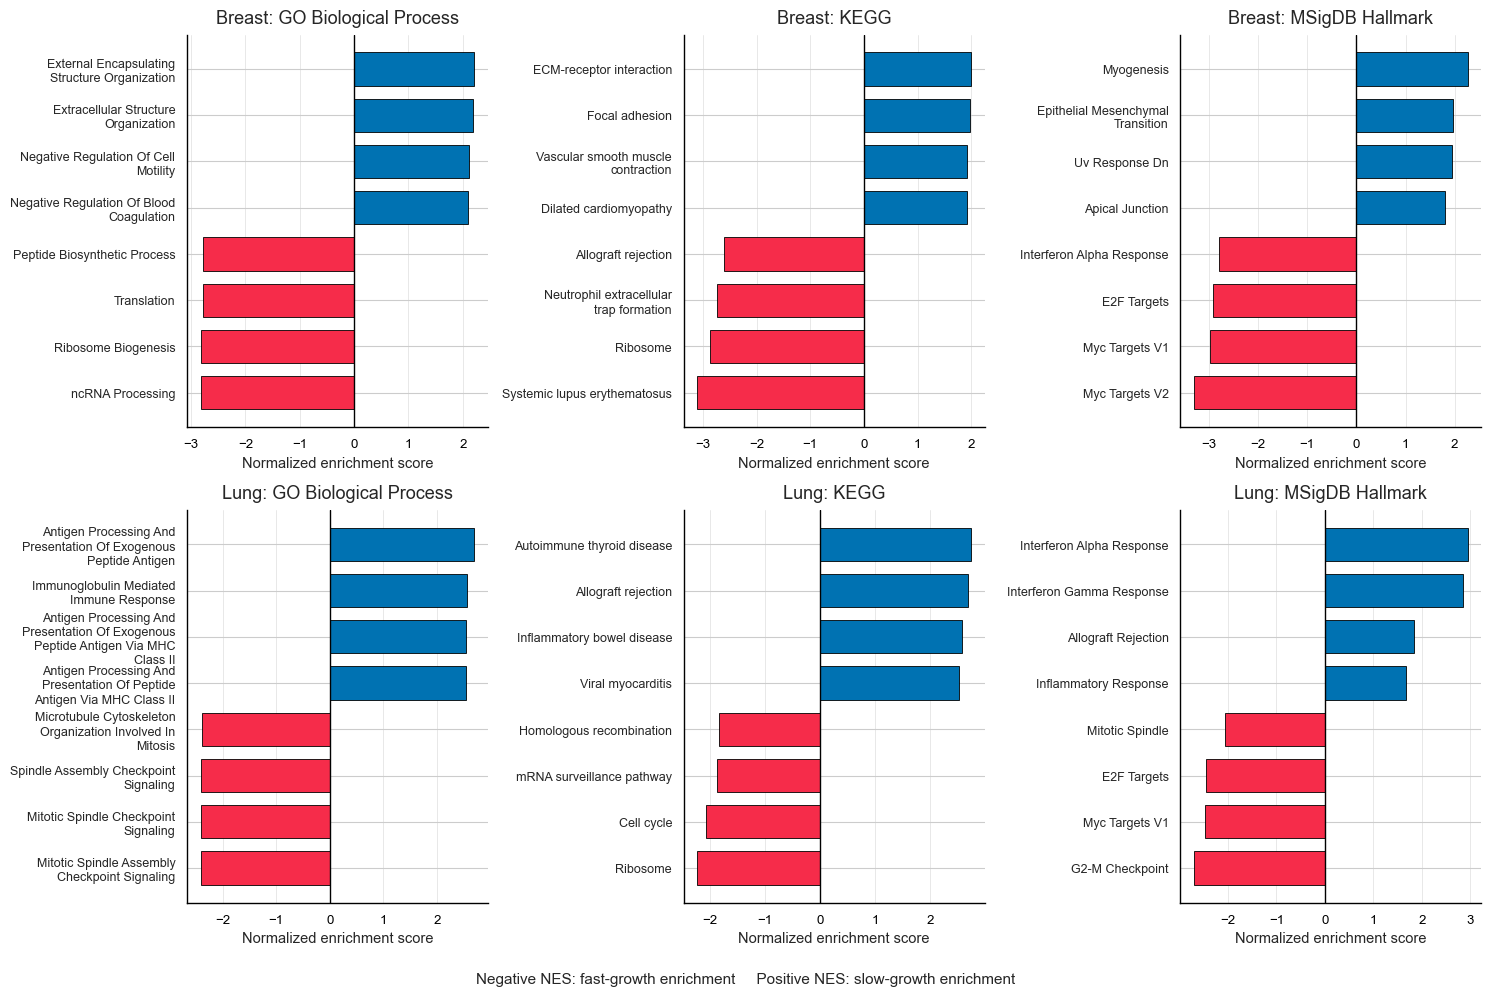

Saved GSEA figure: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate/Figure3_GSEA_GO_KEGG_Hallmark_breast_lung.png


,Term,NES_breast,FDR_breast,NES_lung,FDR_lung,Collection,direction_concordant,best_FDR
2123,Ribosome,-2.864295,0.0,-2.225498,0.0,KEGG,True,0.0
2414,Myc Targets V1,-2.972877,0.0,-2.476838,0.0,MSigDB Hallmark,True,0.0
2415,E2F Targets,-2.912554,0.0,-2.44272,0.0,MSigDB Hallmark,True,0.0
2418,G2-M Checkpoint,-2.272732,0.0,-2.698372,0.0,MSigDB Hallmark,True,0.0
2,Translation (GO:0006412),-2.784026,0.0,-2.19081,0.000392,GO Biological Process,True,0.000392
2421,mTORC1 Signaling,-1.992642,0.000296,-1.883158,0.000538,MSigDB Hallmark,True,0.000538
1,Ribosome Biogenesis (GO:0042254),-2.825106,0.0,-2.113834,0.001402,GO Biological Process,True,0.001402
8,rRNA Processing (GO:0006364),-2.634384,0.0,-2.102565,0.001689,GO Biological Process,True,0.001689
5,Ribonucleoprotein Complex Biogenesis (GO:0022613),-2.672291,0.0,-2.081828,0.002543,GO Biological Process,True,0.002543
28,Mitochondrial Gene Expression (GO:0140053),-2.176157,0.003544,-2.164229,0.000603,GO Biological Process,True,0.003544


In [4]:
# Breast and lung: ranked pathway enrichment using the current ML input matrices
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gseapy as gp
import textwrap
import subprocess
from scipy import stats

FAST_QUANTILE = 0.33
SLOW_QUANTILE = 0.67
GSEA_PERMUTATIONS = 5000
GSEA_MIN_SIZE = 15
GSEA_MAX_SIZE = 500
GSEA_FDR_THRESHOLD = 0.05
GSEA_TOP_PER_DIRECTION = 4
GSEA_SEED = 42

cohort_files = {
    "Breast": PROC_DIR / "rna_doubling_time_merged_breast.csv",
    "Lung": PROC_DIR / "rna_doubling_time_merged_lung.csv",
}
gene_set_libraries = {
    "GO Biological Process": "GO_Biological_Process_2023",
    "KEGG": "KEGG_2021_Human",
    "MSigDB Hallmark": "MSigDB_Hallmark_2020",
}


def build_growth_rank(cohort, expression_file):
    """Rank every input gene by limma's empirical-Bayes moderated t-statistic
    (slow-growth minus fast-growth): per-gene variance estimates are shrunk
    toward a prior fitted across the whole population of genes measured on
    the same samples, the more principled estimator than a per-gene Welch's
    t when per-group sample sizes are this small (9 per group for lung).
    """
    data = pd.read_csv(expression_file, index_col=0)
    target_col = "doubling_time_days"
    if target_col not in data.columns:
        raise ValueError(f"Missing {target_col} in {expression_file}")

    log_dt = np.log1p(pd.to_numeric(data[target_col], errors="raise"))
    fast_cutoff = log_dt.quantile(FAST_QUANTILE)
    slow_cutoff = log_dt.quantile(SLOW_QUANTILE)
    fast_mask = log_dt <= fast_cutoff
    slow_mask = log_dt >= slow_cutoff

    expression = data.drop(columns=target_col).apply(pd.to_numeric, errors="coerce")
    cohort_key = cohort.lower()

    # Hand off to limma (R) for the moderated-t computation: write a samples x
    # genes matrix with a Fast/Slow group column, run compute_limma_ranking.R,
    # read the per-gene moderated t back.
    limma_input_file = PROC_DIR / f"limma_ranking_input_{cohort_key}.csv"
    limma_output_file = PROC_DIR / f"limma_ranking_output_{cohort_key}.csv"
    limma_input = expression.loc[fast_mask | slow_mask].copy()
    limma_input["group"] = np.where(slow_mask.loc[limma_input.index], "Slow", "Fast")
    limma_input.to_csv(limma_input_file)
    subprocess.run(
        ["Rscript", "compute_limma_ranking.R", str(limma_input_file), "group", "Fast", "Slow", str(limma_output_file)],
        check=True,
    )
    limma_result = pd.read_csv(limma_output_file).set_index("Gene")

    rank_table = pd.DataFrame({
        "Gene": expression.columns,
        "ranking_statistic": limma_result["ranking_statistic"].reindex(expression.columns).to_numpy(),
        "unadjusted_p_value": limma_result["unadjusted_p_value"].reindex(expression.columns).to_numpy(),
        "mean_expression_slow": expression.loc[slow_mask].mean(axis=0).to_numpy(),
        "mean_expression_fast": expression.loc[fast_mask].mean(axis=0).to_numpy(),
    })
    rank_table["mean_difference_slow_minus_fast"] = (
        rank_table["mean_expression_slow"] - rank_table["mean_expression_fast"]
    )
    rank_table = (
        rank_table.replace([np.inf, -np.inf], np.nan)
        .dropna(subset=["ranking_statistic"])
        .sort_values("ranking_statistic", ascending=False)
        .reset_index(drop=True)
    )

    rank_table.to_csv(RESULTS_DIR / f"growth_pathway_gene_ranking_{cohort_key}.csv", index=False)
    rank_table[["Gene", "ranking_statistic"]].to_csv(
        RESULTS_DIR / f"growth_pathway_gene_ranking_{cohort_key}.rnk",
        sep="\t", index=False, header=False,
    )
    print(
        f"{cohort}: {fast_mask.sum()} fast and {slow_mask.sum()} slow models; "
        f"ranked {len(rank_table):,} genes from {expression_file.name} (limma moderated-t)"
    )
    return rank_table


rank_tables = {
    cohort: build_growth_rank(cohort, expression_file)
    for cohort, expression_file in cohort_files.items()
}

# Positive NES means enrichment in slow-growing PDXs; negative NES means fast-growing PDXs.
gsea_results = {}
for cohort, rank_table in rank_tables.items():
    for collection_label, library_name in gene_set_libraries.items():
        enrichment = gp.prerank(
            rnk=rank_table[["Gene", "ranking_statistic"]],
            gene_sets=library_name,
            min_size=GSEA_MIN_SIZE, max_size=GSEA_MAX_SIZE,
            permutation_num=GSEA_PERMUTATIONS,
            threads=4, seed=GSEA_SEED,
            outdir=None, no_plot=True, verbose=False,
        )
        result = enrichment.res2d.copy()
        result["Cohort"] = cohort
        result["Collection"] = collection_label
        result["Growth_Direction"] = np.where(
            result["NES"] > 0, "Slow growth", "Fast growth"
        )
        gsea_results[(cohort, collection_label)] = result
        output_name = collection_label.lower().replace(" ", "_")
        result.to_csv(
            RESULTS_DIR / f"growth_gsea_{cohort.lower()}_{output_name}.csv", index=False
        )


def select_pathways_for_plot(result):
    significant = result.loc[result["FDR q-val"] < GSEA_FDR_THRESHOLD].copy()
    positive = (
        significant.loc[significant["NES"] > 0]
        .sort_values(["FDR q-val", "NES"], ascending=[True, False])
        .head(GSEA_TOP_PER_DIRECTION)
    )
    negative = (
        significant.loc[significant["NES"] < 0]
        .sort_values(["FDR q-val", "NES"], ascending=[True, True])
        .head(GSEA_TOP_PER_DIRECTION)
    )
    return pd.concat([negative, positive]).sort_values("NES")


def format_pathway_name(term, collection_label):
    term = str(term).split(" (GO:")[0]
    if collection_label == "MSigDB Hallmark":
        term = term.replace("HALLMARK_", "").replace("_", " " ).title()
    return "\n".join(textwrap.wrap(term, width=28))


color_fast = "#f62c4a"
color_slow = "#0072B2"
fig, axes = plt.subplots(2, 3, figsize=(15, 10), squeeze=False)
for row_index, cohort in enumerate(cohort_files):
    for col_index, collection_label in enumerate(gene_set_libraries):
        ax = axes[row_index, col_index]
        plot_data = select_pathways_for_plot(gsea_results[(cohort, collection_label)])
        if plot_data.empty:
            ax.text(
                0.5, 0.5, f"No pathways at FDR < {GSEA_FDR_THRESHOLD:.2f}",
                transform=ax.transAxes, ha="center", va="center", fontsize=11,
            )
            ax.set_yticks([])
        else:
            labels = [
                format_pathway_name(term, collection_label) for term in plot_data["Term"]
            ]
            colors = [color_slow if nes > 0 else color_fast for nes in plot_data["NES"]]
            ax.barh(
                labels, plot_data["NES"], color=colors,
                edgecolor="black", linewidth=0.6, height=0.72,
            )
        ax.axvline(0, color="black", linewidth=1)
        ax.set_title(f"{cohort}: {collection_label}", fontsize=13, pad=8)
        ax.set_xlabel("Normalized enrichment score", fontsize=10.5)
        ax.tick_params(axis="x", labelsize=9.5, colors="black")
        ax.tick_params(axis="y", labelsize=9)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["bottom"].set_color("black")
        ax.spines["left"].set_color("black")
        ax.grid(axis="x", color="#D9D9D9", linewidth=0.6, alpha=0.7)
        ax.set_axisbelow(True)

fig.text(
    0.5, 0.012,
    "Negative NES: fast-growth enrichment     Positive NES: slow-growth enrichment",
    ha="center", fontsize=11,
)
plt.tight_layout(rect=[0, 0.035, 1, 1])
gsea_plot = RESULTS_DIR / "Figure3_GSEA_GO_KEGG_Hallmark_breast_lung.png"
plt.savefig(gsea_plot, dpi=600, bbox_inches="tight")
plt.savefig(gsea_plot.with_suffix(".pdf"), bbox_inches="tight")
plt.show()

# Save pathways observed in both cohorts, including direction concordance.
cross_cohort_rows = []
for collection_label in gene_set_libraries:
    breast = gsea_results[("Breast", collection_label)][
        ["Term", "NES", "FDR q-val"]
    ].rename(columns={"NES": "NES_breast", "FDR q-val": "FDR_breast"})
    lung = gsea_results[("Lung", collection_label)][
        ["Term", "NES", "FDR q-val"]
    ].rename(columns={"NES": "NES_lung", "FDR q-val": "FDR_lung"})
    shared = breast.merge(lung, on="Term", how="inner", validate="one_to_one")
    shared["Collection"] = collection_label
    shared["direction_concordant"] = np.sign(shared["NES_breast"]) == np.sign(shared["NES_lung"])
    shared["best_FDR"] = shared[["FDR_breast", "FDR_lung"]].max(axis=1)
    cross_cohort_rows.append(shared)

cross_cohort_gsea = (
    pd.concat(cross_cohort_rows, ignore_index=True)
    .sort_values(["direction_concordant", "best_FDR"], ascending=[False, True])
)
cross_cohort_gsea.to_csv(
    RESULTS_DIR / "growth_gsea_cross_cohort_concordance.csv", index=False
)
print(f"Saved GSEA figure: {gsea_plot}")
display(cross_cohort_gsea.head(20))


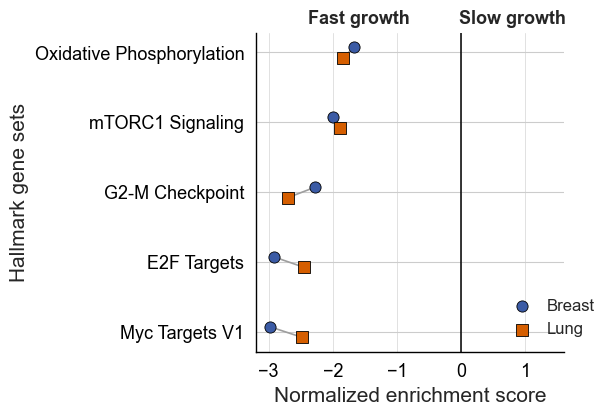

,Pathway,NES_breast,FDR_breast,NES_lung,FDR_lung
0,Myc Targets V1,-2.972877,0.000000,-2.476838,0.000000
1,E2F Targets,-2.912554,0.000000,-2.442720,0.000000
2,G2-M Checkpoint,-2.272732,0.000000,-2.698372,0.000000
3,mTORC1 Signaling,-1.992642,0.000296,-1.883158,0.000538
4,Oxidative Phosphorylation,-1.667013,0.007755,-1.846187,0.000738


Loaded /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate/growth_gsea_cross_cohort_concordance.csv
Saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate/Figure3_Main_Shared_Hallmark_NES.png
Saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate/growth_gsea_figure2e_hallmark_concordant.csv


In [5]:
# Main-figure panel: pathways concordantly enriched in breast and lung PDXs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

concordance_file = RESULTS_DIR / "growth_gsea_cross_cohort_concordance.csv"
shared_pathways = pd.read_csv(concordance_file)

# Hallmark is used for the main panel because it is compact and less redundant than GO.
# Selection is objective: same NES direction and FDR < 0.05 in both cohorts.
main_pathways = shared_pathways.loc[
    (shared_pathways["Collection"] == "MSigDB Hallmark")
    & shared_pathways["direction_concordant"].astype(bool)
    & (shared_pathways["FDR_breast"] < 0.05)
    & (shared_pathways["FDR_lung"] < 0.05)
].copy()
if main_pathways.empty:
    raise ValueError("No concordant Hallmark pathways pass FDR < 0.05 in both cohorts")

main_pathways["mean_NES"] = main_pathways[["NES_breast", "NES_lung"]].mean(axis=1)
main_pathways = main_pathways.sort_values("mean_NES", ascending=True).reset_index(drop=True)
main_pathways["Pathway"] = (
    main_pathways["Term"].str.replace("HALLMARK_", "", regex=False)
    .str.replace("_", " ", regex=False)
)

y_position = np.arange(len(main_pathways))
breast_color = "#3B5BA5"
lung_color = "#D55E00"
fast_color = "#f62c4a"
slow_color = "#0072B2"

fig, ax = plt.subplots(figsize=(6.5, 4.5))
marker_offset = 0.075
for y, breast_nes, lung_nes in zip(
    y_position, main_pathways["NES_breast"], main_pathways["NES_lung"]
):
    ax.plot(
        [breast_nes, lung_nes], [y + marker_offset, y - marker_offset], color="#9E9E9E",
        linewidth=1.2, zorder=1,
    )

ax.scatter(
    main_pathways["NES_breast"], y_position + marker_offset, s=65, marker="o",
    color=breast_color, edgecolor="black", linewidth=0.6, label="Breast", zorder=3,
)
ax.scatter(
    main_pathways["NES_lung"], y_position - marker_offset, s=65, marker="s",
    color=lung_color, edgecolor="black", linewidth=0.6, label="Lung", zorder=3,
)
ax.axvline(0, color="black", linewidth=1.1, zorder=2)
ax.set_yticks(y_position)
ax.set_yticklabels(main_pathways["Pathway"], fontsize=13)
ax.set_xlabel("Normalized enrichment score", fontsize=15)
ax.set_xlim(-3.2, 1.6)
# ax.set_title("Shared Hallmark pathway enrichment", fontsize=14, pad=22)
# Centered within each half (data coordinates, x) / axes fraction (y), so
# each label sits in the middle of its own side of the zero line rather than
# hugging the divider -- computed from the actual xlim rather than hardcoded,
# so it stays centered if xlim changes again.
label_transform = ax.get_xaxis_transform()
xlim_lo, xlim_hi = ax.get_xlim()
ax.text(
    xlim_lo / 2, 1.015, "Fast growth", transform=label_transform,
    ha="center", va="bottom", fontsize=13, fontweight="bold",
)
ax.text(
    xlim_hi / 2, 1.015, "Slow growth", transform=label_transform,
    ha="center", va="bottom", fontsize=13, fontweight="bold",
)
ax.legend(loc="lower right", bbox_to_anchor=(1.15, 0), frameon=False, fontsize=12, handletextpad=0.5)
ax.grid(axis="x", color="#D9D9D9", linewidth=0.7, alpha=0.8)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_color("black")
ax.spines["left"].set_color("black")
ax.tick_params(axis="x", labelsize=13, colors="black")
ax.tick_params(axis="y", colors="black")
ax.set_ylabel("Hallmark gene sets", fontsize=15)

# fig.text(
#     0.5, 0.012, "Concordant direction; FDR < 0.05 in both cohorts",
#     ha="center", va="bottom", fontsize=8.5, color="#555555",
# )
plt.tight_layout(rect=[0, 0.055, 1, 1])
main_pathway_plot = RESULTS_DIR / "Figure3_Main_Shared_Hallmark_NES.png"
plt.savefig(main_pathway_plot, dpi=600, bbox_inches="tight")
plt.savefig(main_pathway_plot.with_suffix(".pdf"), bbox_inches="tight")
plt.show()

main_pathways_table = main_pathways[[
    "Pathway", "NES_breast", "FDR_breast", "NES_lung", "FDR_lung"
]]
main_pathways_file = RESULTS_DIR / "growth_gsea_figure2e_hallmark_concordant.csv"
main_pathways_table.to_csv(main_pathways_file, index=False)

display(main_pathways_table)
print(f"Loaded {concordance_file}")
print(f"Saved {main_pathway_plot}")
print(f"Saved {main_pathways_file}")
